# Steinbeck, lemons e domanda costretta  
## Versione estesa, elegante e interattiva per Jupyter

Questo notebook costruisce un **modello agent-based (ABM)** in Python ispirato al testo su *The Grapes of Wrath* e alla discussione teorica che distingue tra:

- il classico **market for lemons** di Akerlof;
- una versione **storico-sociale alla Steinbeck**, in cui contano anche:
  - **domanda costretta**;
  - **asimmetria informativa**;
  - **potere locale/monopolistico dei venditori**;
  - **discriminazione di prezzo**;
  - **interazione one-shot**;
  - **assenza di istituzioni neutralizzatrici**.

Il testo di partenza insiste sul fatto che la spiegazione **non può essere ridotta al semplice eccesso di domanda** e che i compratori sono soggetti socialmente vulnerabili — contadini, immigrati, stranieri — quindi meno informati non solo sulla qualità del bene ma anche sulle **regole di comportamento del mercato**. Inoltre il testo sottolinea il ruolo di venditori locali con potere di mercato, domanda urgente, opportunismo e mancanza di standard minimi di qualità. fileciteturn1file0L1-L18 fileciteturn1file2L1-L18

L'obiettivo qui non è “dimostrare” il testo in senso stretto, ma costruire un **laboratorio computazionale** utile per ragionare su queste ipotesi.


## 1. Idea teorica del modello

### 1.1. Punto di partenza: Akerlof
Nel modello di Akerlof, la qualità è eterogenea ma il compratore non osserva bene la qualità prima dell'acquisto. Ne segue una dinamica di **selezione avversa**: i compratori offrono un prezzo medio, i venditori dei beni migliori escono dal mercato, e restano soprattutto i beni peggiori. Il testo fornito richiama esplicitamente questo schema, ma sostiene anche che esso **non basta** per spiegare il mercato descritto da Steinbeck. fileciteturn1file3L6-L18

### 1.2. Perché Steinbeck richiede un'estensione
Nel testo compaiono altri elementi:

- **offerta monopolistica o collusiva a livello locale**;
- **molti acquirenti scarsamente informati**;
- **domanda costretta**, cioè acquirenti che devono comprare subito;
- **un solo incontro** tra domanda e offerta, che incentiva l'opportunismo;
- **discriminazione del prezzo** in base alla vulnerabilità o al reddito presunto;
- tecniche relazionali per mettere il compratore “sotto obbligazione”;
- **assenza di istituzioni** che impongano una qualità minima. fileciteturn1file2L1-L18

### 1.3. Intuizione dell'ABM
Rappresentiamo quindi il mercato come un sistema in cui:

- i **venditori** scelgono se spingere auto buone o lemons;
- i **compratori** differiscono per reddito, urgenza, alfabetizzazione di mercato, capacità di ispezione e memoria delle frodi;
- la **probabilità di acquisto** dipende sia dal prezzo sia dalla pressione della necessità;
- la **redditività dei lemons** cresce quando il compratore è vulnerabile e le istituzioni sono deboli.

Il punto teorico è che il mercato “alla Steinbeck” non è solo un problema di qualità non osservabile: è un problema di **asimmetria sociale**, oltre che informativa.


## 2. Architettura del modello

Abbiamo due tipi di agenti.

### Venditori
Ogni venditore controlla un piccolo mercato locale di auto usate e decide:
- la quota di auto **buone** vs **lemons** da offrire;
- il **markup** applicato;
- il grado di **aggressività commerciale**;
- il grado di **discriminazione di prezzo**;
- se adottare una strategia più predatoria o più prudente.

### Compratori
Ogni compratore è caratterizzato da:
- **budget**;
- **urgenza** della partenza / bisogno;
- **market literacy**: comprensione delle regole del mercato;
- **inspection skill**: capacità di riconoscere la qualità;
- **trust** iniziale;
- **memoria** di esperienze negative, che può alterare il comportamento futuro.

### Istituzioni
Un blocco parametrico rappresenta:
- standard minimi di qualità;
- probabilità di ispezione;
- sanzioni;
- garanzie o rimedi parziali.

Questo consente di confrontare tre famiglie di scenari:
1. **Solo Akerlof**
2. **Steinbeck esteso**
3. **Steinbeck con istituzioni**


In [1]:
from dataclasses import dataclass, asdict
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown
    HAS_WIDGETS = True
except Exception:
    from IPython.display import Markdown
    HAS_WIDGETS = False

plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


In [2]:
@dataclass
class Params:
    # Struttura del mercato
    n_buyers: int = 700
    n_sellers: int = 28
    periods: int = 60

    # Costi e qualità tecnica
    cost_good: float = 70.0
    cost_lemon: float = 25.0
    durability_good: float = 0.88
    durability_lemon: float = 0.28

    # Domanda e vulnerabilità
    forced_demand: float = 0.78          # forza della necessità di acquistare
    income_dispersion: float = 22.0      # dispersione del budget
    literacy_mean: float = 0.38          # comprensione del mercato
    inspection_mean: float = 0.32        # capacità di ispezionare la qualità
    trust_mean: float = 0.66             # fiducia iniziale

    # Lato offerta
    local_market_power: float = 0.78     # potere locale/monopolistico
    seller_aggressiveness: float = 0.72  # pressione commerciale
    price_discrimination: float = 0.62   # capacità di stimare e spremere il cliente
    lemon_push: float = 0.68             # incentivo a spingere lemons

    # Istituzioni
    institution_strength: float = 0.08
    inspection_probability: float = 0.05
    min_quality_standard: float = 0.00
    penalty_if_caught: float = 22.0
    warranty_refund_share: float = 0.00

params = Params()
params


Params(n_buyers=700, n_sellers=28, periods=60, cost_good=70.0, cost_lemon=25.0, durability_good=0.88, durability_lemon=0.28, forced_demand=0.78, income_dispersion=22.0, literacy_mean=0.38, inspection_mean=0.32, trust_mean=0.66, local_market_power=0.78, seller_aggressiveness=0.72, price_discrimination=0.62, lemon_push=0.68, institution_strength=0.08, inspection_probability=0.05, min_quality_standard=0.0, penalty_if_caught=22.0, warranty_refund_share=0.0)

In [3]:
class Buyer:
    def __init__(self, idx, p: Params):
        self.idx = idx
        self.budget = np.clip(np.random.normal(95, p.income_dispersion), 30, 190)
        self.urgency = np.clip(np.random.beta(5, 2), 0, 1)
        self.market_literacy = np.clip(np.random.normal(p.literacy_mean, 0.16), 0, 1)
        self.inspection_skill = np.clip(np.random.normal(p.inspection_mean, 0.16), 0, 1)
        self.trust = np.clip(np.random.normal(p.trust_mean, 0.12), 0, 1)
        self.bad_experiences = 0
        self.has_car = False
        self.failed_trip = False

    @property
    def vulnerability(self):
        # alta urgenza + bassa literacy + bassa inspection = maggiore vulnerabilità
        v = (0.45 * self.urgency
             + 0.30 * (1 - self.market_literacy)
             + 0.25 * (1 - self.inspection_skill))
        return float(np.clip(v, 0, 1))

    def update_after_purchase(self, got_lemon: bool):
        if got_lemon:
            self.bad_experiences += 1
            self.trust = max(0, self.trust - 0.10)
        else:
            self.trust = min(1, self.trust + 0.02)


In [4]:
class Seller:
    def __init__(self, idx, p: Params):
        self.idx = idx
        self.p = p
        self.reputation = np.clip(np.random.normal(0.5, 0.12), 0, 1)
        self.cash = 0.0

    def choose_quality_mix(self):
        # più lemon_push e più potere locale => più lemons in vendita
        pressure = (0.50 * self.p.lemon_push
                    + 0.35 * self.p.local_market_power
                    + 0.15 * (1 - self.reputation))
        share_lemons = np.clip(np.random.normal(pressure, 0.08), 0.05, 0.95)
        return share_lemons

    def quote_price(self, buyer, quality):
        base = 92 if quality == "good" else 72

        # markup più alto se il venditore ha potere locale
        market_markup = 1 + 0.45 * self.p.local_market_power

        # discriminazione di prezzo su budget/vulnerabilità percepiti
        discr = 1 + self.p.price_discrimination * (
            0.55 * (buyer.budget / 140) + 0.45 * buyer.vulnerability
        )

        # pressione commerciale: peggiora il prezzo soprattutto sui lemons
        aggression = 1 + self.p.seller_aggressiveness * (0.18 if quality == "good" else 0.28)

        # istituzioni frenano gli eccessi
        institution_discount = 1 - 0.20 * self.p.institution_strength

        price = base * market_markup * discr * aggression * institution_discount

        # minimo vincolato ai costi
        min_cost = self.p.cost_good if quality == "good" else self.p.cost_lemon
        return max(min_cost * 1.03, price)


In [5]:
class UsedCarMarketABM:
    def __init__(self, p: Params, seed: int = 42):
        self.p = p
        self.seed = seed
        np.random.seed(seed)
        random.seed(seed)
        self.sellers = [Seller(i, p) for i in range(p.n_sellers)]
        self.history = []

    def perceived_quality(self, buyer, true_quality):
        if true_quality == "good":
            q_true = self.p.durability_good
        else:
            q_true = self.p.durability_lemon

        signal_precision = 0.15 + 0.70 * buyer.inspection_skill + 0.15 * buyer.market_literacy
        noise_scale = max(0.02, 0.22 * (1 - signal_precision))
        perceived = np.clip(np.random.normal(q_true, noise_scale), 0, 1)
        return perceived

    def purchase_probability(self, buyer, price, perceived_quality):
        affordability = np.clip(1 - max(0, price - buyer.budget) / max(buyer.budget, 1), 0, 1)
        utility_signal = 0.55 * perceived_quality + 0.25 * buyer.trust + 0.20 * affordability

        # La domanda costretta attenua il rifiuto anche quando il prezzo è alto o la qualità è dubbia
        forced_component = self.p.forced_demand * buyer.urgency

        decision_score = (
            0.45 * utility_signal
            + 0.40 * forced_component
            + 0.15 * (1 - buyer.bad_experiences / 5)
        )
        return float(np.clip(decision_score, 0, 1))

    def seller_offer(self, seller, buyer):
        share_lemons = seller.choose_quality_mix()
        quality = "lemon" if np.random.rand() < share_lemons else "good"

        # standard minimi: se attivi, bloccano alcuni lemons troppo scadenti
        if quality == "lemon" and self.p.min_quality_standard > 0:
            if self.p.durability_lemon < self.p.min_quality_standard and np.random.rand() < self.p.institution_strength:
                quality = "good"

        price = seller.quote_price(buyer, quality)
        return quality, price, share_lemons

    def institutional_outcome(self, seller, quality):
        penalty = 0.0
        refund = 0.0
        if quality == "lemon" and np.random.rand() < self.p.inspection_probability * self.p.institution_strength:
            penalty = self.p.penalty_if_caught
            refund = self.p.warranty_refund_share
            seller.reputation = max(0, seller.reputation - 0.04)
        return penalty, refund

    def step(self, t):
        buyers = [Buyer(i + t * self.p.n_buyers, self.p) for i in range(self.p.n_buyers)]

        transactions = 0
        lemons_sold = 0
        good_sold = 0
        total_price = 0.0
        total_profit = 0.0
        total_buyer_welfare = 0.0
        deceptions = 0
        failed_trips = 0
        no_purchase = 0
        seller_mix = []

        for buyer in buyers:
            seller = random.choice(self.sellers)
            quality, price, mix = self.seller_offer(seller, buyer)
            seller_mix.append(mix)

            perceived_quality = self.perceived_quality(buyer, quality)
            p_buy = self.purchase_probability(buyer, price, perceived_quality)

            if np.random.rand() < p_buy:
                buyer.has_car = True
                transactions += 1
                total_price += price

                if quality == "good":
                    cost = self.p.cost_good
                    durability = self.p.durability_good
                    good_sold += 1
                else:
                    cost = self.p.cost_lemon
                    durability = self.p.durability_lemon
                    lemons_sold += 1

                penalty, refund_share = self.institutional_outcome(seller, quality)
                refund = price * refund_share if quality == "lemon" else 0.0

                profit = price - cost - penalty - refund
                seller.cash += profit
                total_profit += profit

                # welfare grezzo del compratore
                use_value = durability * 120
                welfare = use_value - price + 18 * buyer.urgency
                if quality == "lemon":
                    welfare -= 20 * (1 - buyer.inspection_skill)
                welfare += refund
                total_buyer_welfare += welfare

                deception_gap = max(0, perceived_quality - durability)
                deceptions += int(deception_gap > 0.18)

                if quality == "lemon" and np.random.rand() < (1 - durability):
                    buyer.failed_trip = True
                    failed_trips += 1

                buyer.update_after_purchase(quality == "lemon")
            else:
                no_purchase += 1
                if buyer.urgency > 0.72:
                    buyer.failed_trip = True
                    failed_trips += 1

        row = {
            "period": t,
            "transactions": transactions,
            "share_lemons_sold": lemons_sold / transactions if transactions else np.nan,
            "share_good_sold": good_sold / transactions if transactions else np.nan,
            "avg_price": total_price / transactions if transactions else np.nan,
            "avg_buyer_welfare": total_buyer_welfare / transactions if transactions else np.nan,
            "avg_deception": deceptions / transactions if transactions else np.nan,
            "failed_trips": failed_trips,
            "no_purchase": no_purchase,
            "total_profit": total_profit,
            "share_good_strategy": 1 - np.mean(seller_mix) if seller_mix else np.nan,
        }
        self.history.append(row)
        return row

    def run(self):
        for t in range(self.p.periods):
            self.step(t)
        return pd.DataFrame(self.history)


In [6]:
def plot_main_results(df, title="Scenario"):
    fig, ax = plt.subplots()
    ax.plot(df["period"], df["share_lemons_sold"], label="Quota lemons vendute")
    ax.plot(df["period"], df["avg_deception"], label="Deception media")
    ax.plot(df["period"], df["share_good_strategy"], label="Quota offerta buona")
    ax.set_title(title)
    ax.set_xlabel("Periodo")
    ax.set_ylabel("Valore")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(df["period"], df["avg_price"], label="Prezzo medio")
    ax.plot(df["period"], df["avg_buyer_welfare"], label="Benessere medio compratore")
    ax.set_title(title + " — prezzi e benessere")
    ax.set_xlabel("Periodo")
    ax.legend()
    plt.show()

def summarize_scenario(df):
    cols = ["share_lemons_sold", "avg_deception", "share_good_strategy",
            "avg_price", "avg_buyer_welfare", "failed_trips", "no_purchase", "total_profit"]
    return df[cols].mean().to_frame("mean").T.round(3)

def run_scenario(name, base=None, seed=42, **kwargs):
    base_dict = asdict(base or params)
    p = Params(**{**base_dict, **kwargs})
    model = UsedCarMarketABM(p, seed=seed)
    df = model.run()
    df["scenario"] = name
    return df, p


## 3. Esecuzione scenario base: Steinbeck esteso

Questo è lo scenario di riferimento: domanda costretta alta, forte potere locale del venditore, discriminazione di prezzo significativa, istituzioni deboli.


,period,transactions,share_lemons_sold,share_good_sold,avg_price,avg_buyer_welfare,avg_deception,failed_trips,no_purchase,total_profit,share_good_strategy,scenario
0,0,415,0.684337,0.315663,174.157469,-114.105127,0.040964,339,285,56005.349578,0.309588,Steinbeck esteso
1,1,382,0.612565,0.387435,176.494752,-109.813580,0.078534,327,318,51210.995183,0.306508,Steinbeck esteso
2,2,410,0.590244,0.409756,176.498712,-108.385016,0.034146,331,290,54532.471805,0.312727,Steinbeck esteso
3,3,384,0.653646,0.346354,175.215321,-112.698481,0.046875,330,316,51653.683343,0.309101,Steinbeck esteso
4,4,399,0.651629,0.348371,174.993285,-111.957303,0.065163,320,301,53570.320728,0.305920,Steinbeck esteso


,share_lemons_sold,avg_deception,share_good_strategy,avg_price,avg_buyer_welfare,failed_trips,no_purchase,total_profit
mean,0.647,0.053,0.304,175.369,-112.028,333.283,291.933,54859.229


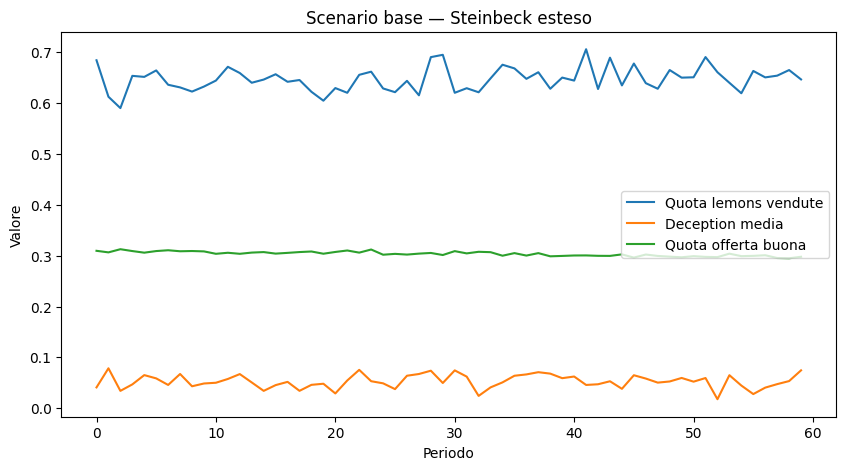

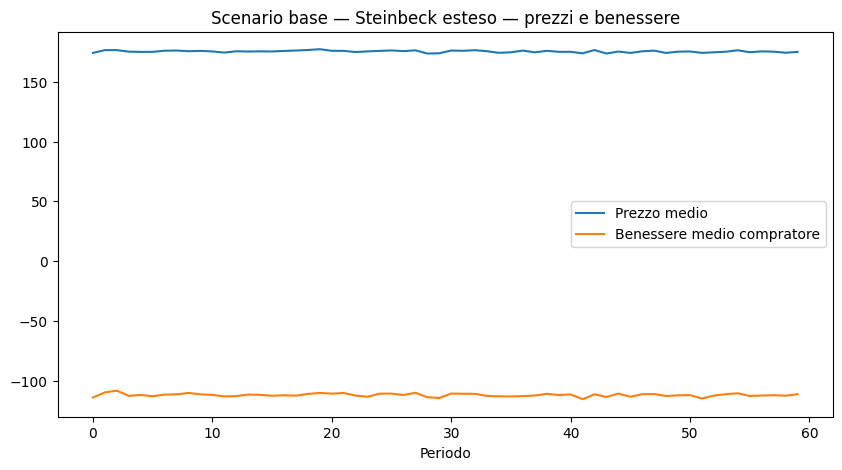

In [7]:
df_base, p_base = run_scenario("Steinbeck esteso", params, seed=42)
display(df_base.head())
display(summarize_scenario(df_base))
plot_main_results(df_base, "Scenario base — Steinbeck esteso")


## 4. Confronto tra scenari

Confrontiamo ora tre mondi:

### Scenario A — Solo Akerlof
C'è asimmetria informativa, ma la domanda è meno costretta, il potere locale del venditore è più basso, la discriminazione di prezzo è più debole. Qui vogliamo avvicinarci al **nucleo classico** del market for lemons.

### Scenario B — Steinbeck esteso
Aggiungiamo gli elementi storico-sociali messi in evidenza nel testo: vulnerabilità dei compratori, urgenza, pressione commerciale, opportunismo one-shot e monopolio locale. fileciteturn1file2L1-L18

### Scenario C — Con istituzioni
Manteniamo l'ambiente “alla Steinbeck”, ma introduciamo:
- probabilità di ispezione;
- sanzioni;
- standard minimi;
- rimborso parziale / garanzia.

Questo permette di ragionare non solo sulla diagnosi teorica, ma anche sulle **condizioni di policy** che potrebbero modificare l'esito del mercato.


In [8]:
df_akerlof, _ = run_scenario(
    "Solo Akerlof",
    params,
    seed=42,
    forced_demand=0.28,
    local_market_power=0.25,
    seller_aggressiveness=0.25,
    price_discrimination=0.18,
    lemon_push=0.45,
    institution_strength=0.05,
    inspection_probability=0.02,
    min_quality_standard=0.0,
    warranty_refund_share=0.0,
)

df_steinbeck, _ = run_scenario(
    "Steinbeck esteso",
    params,
    seed=43,
)

df_institutions, _ = run_scenario(
    "Con istituzioni",
    params,
    seed=44,
    institution_strength=0.70,
    inspection_probability=0.45,
    min_quality_standard=0.35,
    penalty_if_caught=38.0,
    warranty_refund_share=0.20,
    lemon_push=0.58,
)

df_all = pd.concat([df_akerlof, df_steinbeck, df_institutions], ignore_index=True)
summary = (
    df_all.groupby("scenario")[[
        "share_lemons_sold", "avg_deception", "share_good_strategy",
        "avg_price", "avg_buyer_welfare", "failed_trips", "no_purchase", "total_profit"
    ]]
    .mean()
    .round(3)
    .sort_values("share_lemons_sold", ascending=False)
)
summary


,share_lemons_sold,avg_deception,share_good_strategy,avg_price,avg_buyer_welfare,failed_trips,no_purchase,total_profit
scenario,,,,,,,,
Steinbeck esteso,0.648,0.053,0.306,175.328,-112.154,331.950,293.417,54662.259
Solo Akerlof,0.335,0.030,0.609,110.987,-21.069,261.650,331.333,20660.073
Con istituzioni,0.184,0.016,0.296,166.558,-62.046,176.883,240.267,46488.006


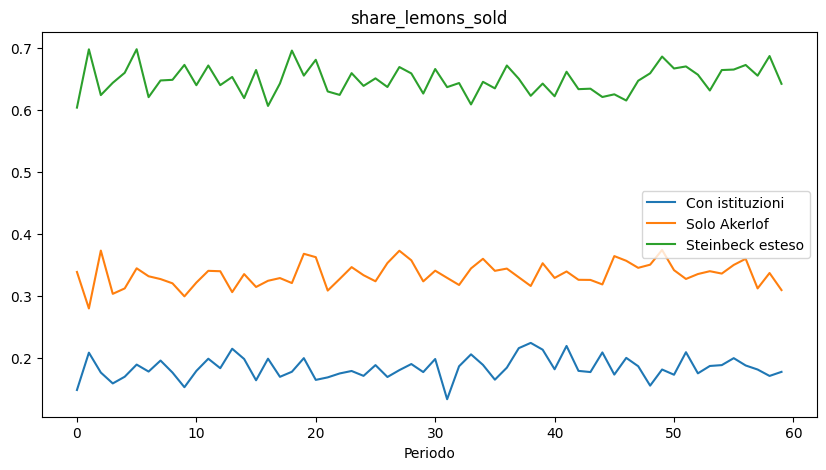

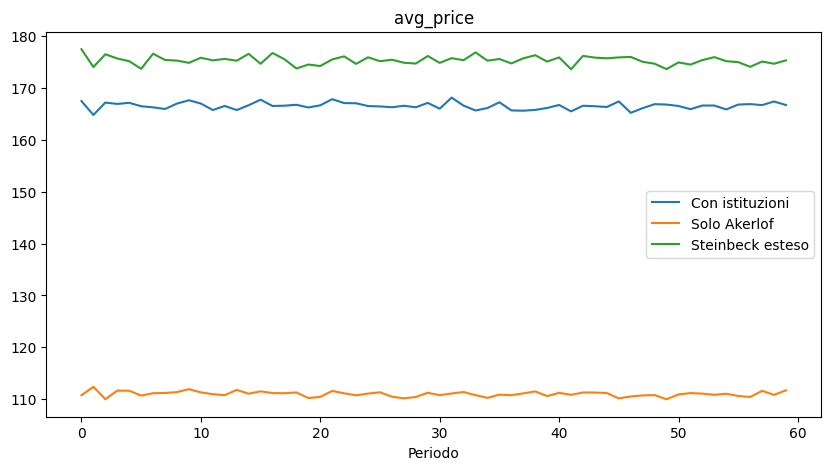

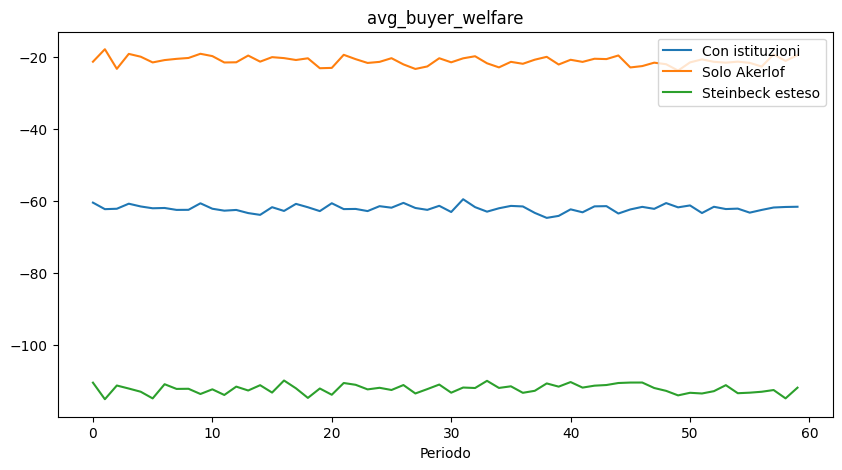

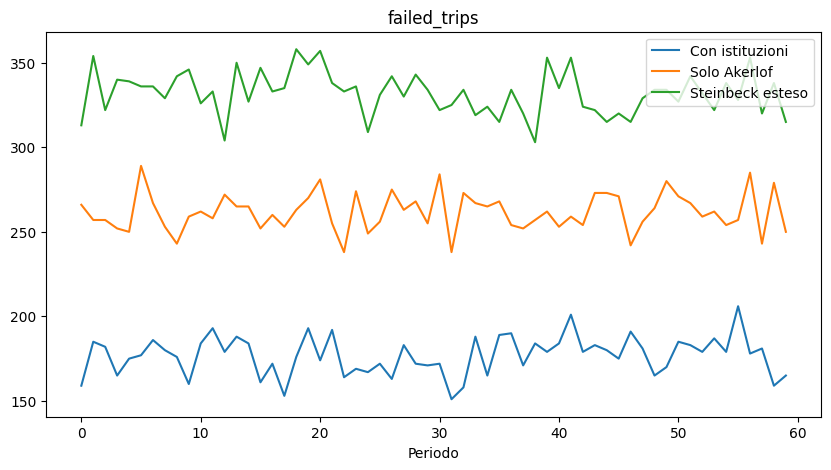

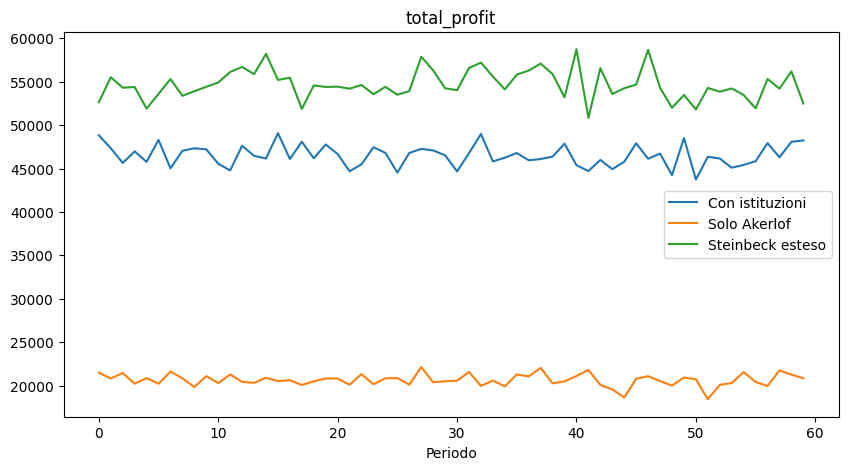

In [9]:
for metric in ["share_lemons_sold", "avg_price", "avg_buyer_welfare", "failed_trips", "total_profit"]:
    fig, ax = plt.subplots()
    for scenario, grp in df_all.groupby("scenario"):
        ax.plot(grp["period"], grp[metric], label=scenario)
    ax.set_title(metric)
    ax.set_xlabel("Periodo")
    ax.legend()
    plt.show()


## 5. Lettura economica del confronto

Il modello tende a suggerire quattro risultati interpretativi.

### 5.1. La sola asimmetria informativa non basta sempre
Nel caso Akerlof puro, i lemons possono prevalere, ma non necessariamente con la stessa intensità distruttiva del mondo descritto da Steinbeck. Il testo infatti sostiene che occorre aggiungere elementi relativi alla struttura dell'offerta e alle caratteristiche socio-antropologiche della domanda. fileciteturn1file3L16-L18

### 5.2. La domanda costretta cambia radicalmente l'esito
Quando i compratori **devono** acquistare, il rifiuto disciplinante del mercato si indebolisce. Anche un prezzo alto o un segnale qualitativo mediocre non bloccano l'acquisto. La necessità riduce l'efficacia del meccanismo concorrenziale.

### 5.3. Potere locale + discriminazione di prezzo + one-shot opportunism
Questa triade è centrale nel testo:
- il venditore non teme molto la reputazione di lungo periodo;
- può spremere il compratore stimandone il budget;
- può vendere merce peggiore perché l'incontro è episodico.

Ne segue che il lemon non è solo il prodotto di una media informativa sfavorevole: è spesso il prodotto di una **strategia deliberata di sfruttamento**.

### 5.4. Le istituzioni possono riallineare gli incentivi
Standard minimi, ispezioni, sanzioni e garanzie non eliminano automaticamente l'asimmetria informativa, ma possono abbassare la convenienza privata del comportamento predatorio.


## 6. Versione interattiva elegante per uso online

La cella seguente crea un piccolo **explorer interattivo** con slider.  
È pensato per Jupyter/Notebook o JupyterLab. Se pubblichi il notebook online, puoi anche trasformarlo in una mini-app con **Voilà**.

Parametri chiave da muovere:
- `forced_demand`
- `local_market_power`
- `price_discrimination`
- `institution_strength`
- `inspection_probability`
- `min_quality_standard`


In [10]:
def interactive_run(
    forced_demand=0.78,
    local_market_power=0.78,
    price_discrimination=0.62,
    seller_aggressiveness=0.72,
    lemon_push=0.68,
    institution_strength=0.08,
    inspection_probability=0.05,
    min_quality_standard=0.00,
    warranty_refund_share=0.00,
    periods=50,
    seed=42,
):
    p = Params(
        n_buyers=params.n_buyers,
        n_sellers=params.n_sellers,
        periods=int(periods),
        cost_good=params.cost_good,
        cost_lemon=params.cost_lemon,
        durability_good=params.durability_good,
        durability_lemon=params.durability_lemon,
        forced_demand=forced_demand,
        income_dispersion=params.income_dispersion,
        literacy_mean=params.literacy_mean,
        inspection_mean=params.inspection_mean,
        trust_mean=params.trust_mean,
        local_market_power=local_market_power,
        seller_aggressiveness=seller_aggressiveness,
        price_discrimination=price_discrimination,
        lemon_push=lemon_push,
        institution_strength=institution_strength,
        inspection_probability=inspection_probability,
        min_quality_standard=min_quality_standard,
        penalty_if_caught=params.penalty_if_caught,
        warranty_refund_share=warranty_refund_share,
    )

    df, _ = run_scenario("Interactive", p, seed=seed)

    display(Markdown(
        f"""
### Lettura sintetica
- **Quota media lemons vendute**: `{df['share_lemons_sold'].mean():.3f}`
- **Prezzo medio**: `{df['avg_price'].mean():.2f}`
- **Benessere medio compratori**: `{df['avg_buyer_welfare'].mean():.2f}`
- **Viaggi falliti medi per periodo**: `{df['failed_trips'].mean():.2f}`
- **Profitto medio totale per periodo**: `{df['total_profit'].mean():.2f}`
"""
    ))

    display(summarize_scenario(df))
    plot_main_results(df, "Esploratore interattivo")


In [11]:
if HAS_WIDGETS:
    controls = widgets.interactive(
        interactive_run,
        forced_demand=widgets.FloatSlider(value=0.78, min=0.0, max=1.0, step=0.02, description="forced_demand"),
        local_market_power=widgets.FloatSlider(value=0.78, min=0.0, max=1.0, step=0.02, description="local_power"),
        price_discrimination=widgets.FloatSlider(value=0.62, min=0.0, max=1.0, step=0.02, description="price_disc"),
        seller_aggressiveness=widgets.FloatSlider(value=0.72, min=0.0, max=1.0, step=0.02, description="aggressive"),
        lemon_push=widgets.FloatSlider(value=0.68, min=0.0, max=1.0, step=0.02, description="lemon_push"),
        institution_strength=widgets.FloatSlider(value=0.08, min=0.0, max=1.0, step=0.02, description="institutions"),
        inspection_probability=widgets.FloatSlider(value=0.05, min=0.0, max=1.0, step=0.02, description="inspect_prob"),
        min_quality_standard=widgets.FloatSlider(value=0.00, min=0.0, max=1.0, step=0.02, description="min_quality"),
        warranty_refund_share=widgets.FloatSlider(value=0.00, min=0.0, max=0.5, step=0.02, description="refund"),
        periods=widgets.IntSlider(value=50, min=10, max=120, step=5, description="periods"),
        seed=widgets.IntSlider(value=42, min=1, max=999, step=1, description="seed"),
    )
    display(controls)
else:
    print("ipywidgets non disponibile in questo ambiente. Puoi comunque chiamare interactive_run(...) manualmente.")


interactive(children=(FloatSlider(value=0.78, description='forced_demand', max=1.0, step=0.02), FloatSlider(va…

## 7. Una griglia di esperimenti riproducibili

La cella seguente costruisce automaticamente una piccola **matrice sperimentale** utile per analisi più sistematiche o per una futura pubblicazione online.


In [12]:
experiment_rows = []
for fd in [0.2, 0.5, 0.8]:
    for lmp in [0.2, 0.5, 0.8]:
        for inst in [0.0, 0.4, 0.8]:
            df, _ = run_scenario(
                "grid",
                params,
                seed=42,
                forced_demand=fd,
                local_market_power=lmp,
                institution_strength=inst,
                inspection_probability=max(0.02, inst * 0.5),
                min_quality_standard=inst * 0.35,
                warranty_refund_share=inst * 0.2,
            )
            experiment_rows.append({
                "forced_demand": fd,
                "local_market_power": lmp,
                "institution_strength": inst,
                "share_lemons_sold": df["share_lemons_sold"].mean(),
                "avg_price": df["avg_price"].mean(),
                "avg_buyer_welfare": df["avg_buyer_welfare"].mean(),
                "failed_trips": df["failed_trips"].mean(),
                "total_profit": df["total_profit"].mean(),
            })

df_grid = pd.DataFrame(experiment_rows).round(3)
df_grid.head(12)


,forced_demand,local_market_power,institution_strength,share_lemons_sold,avg_price,avg_buyer_welfare,failed_trips,total_profit
0,0.2,0.2,0.0,0.415,149.974,-66.979,295.133,32064.572
1,0.2,0.2,0.4,0.466,136.745,-57.747,308.250,28354.982
2,0.2,0.2,0.8,0.487,124.371,-44.758,312.750,23227.123
3,0.2,0.5,0.0,0.523,165.329,-91.620,323.400,36263.779
4,0.2,0.5,0.4,0.583,150.451,-81.262,336.450,32334.223
5,0.2,0.5,0.8,0.598,136.947,-65.769,338.750,27090.928
6,0.2,0.8,0.0,0.628,179.988,-115.237,347.617,40045.406
7,0.2,0.8,0.4,0.701,163.367,-104.081,362.400,35700.644
8,0.2,0.8,0.8,0.714,148.731,-86.126,364.300,30062.344
9,0.5,0.2,0.0,0.433,149.560,-67.963,281.883,38026.324


In [13]:
pivot = df_grid.pivot_table(
    index="forced_demand",
    columns=["local_market_power", "institution_strength"],
    values="share_lemons_sold"
)
pivot


local_market_power      0.2                  0.5                  0.8         \
institution_strength    0.0    0.4    0.8    0.0    0.4    0.8    0.0    0.4   
forced_demand                                                                  
0.2                   0.415  0.466  0.487  0.523  0.583  0.598  0.628  0.701   
0.5                   0.433  0.485  0.502  0.537  0.594  0.615  0.639  0.708   
0.8                   0.438  0.495  0.511  0.545  0.611  0.614  0.655  0.719   

local_market_power           
institution_strength    0.8  
forced_demand                
0.2                   0.714  
0.5                   0.722  
0.8                   0.733

## 8. Come mettere il notebook online

Per una pubblicazione semplice hai almeno tre strade:

### A. GitHub + nbviewer
Metti il notebook in un repository GitHub.  
È la strada più semplice per **farlo leggere**.

### B. Voilà
Se vuoi che la parte con slider diventi una piccola app web, puoi usare:
```bash
pip install voila ipywidgets
voila nome_notebook.ipynb
```

### C. JupyterLite o Binder
Per farlo eseguire nel browser senza installazione locale, puoi pensare a:
- **Binder**;
- **JupyterLite**;
- oppure un tuo server Jupyter/Hub.

Per un uso didattico o di discussione, **Voilà** è probabilmente la soluzione più elegante.


## 9. Estensioni possibili

Per sviluppare ulteriormente il modello, si possono aggiungere:

1. **spazio esplicito**: città, strade, traiettorie verso la California;
2. **reputazione locale** dei venditori e passaparola tra compratori;
3. **credito / debito** per l'acquisto dell'auto;
4. **eterogeneità dei venditori** più ricca: piccoli operatori, cartelli, rivenditori “semi-onesti”;
5. **shock macro**: ondate migratorie, crisi occupazionali, scarsità di offerta;
6. **validazione indiretta** del modello tramite pattern qualitativi coerenti con il testo.

Nella tua prospettiva di ricerca, questo ABM può essere visto come un piccolo laboratorio per passare da una lettura puramente letteraria o teorica a una **struttura esplicita di meccanismi causali simulabili**.


## 10. Conclusione

Il messaggio teorico del notebook è questo:

> Nel mercato descritto da Steinbeck, i beni cattivi non prevalgono soltanto perché la qualità è poco osservabile. Prevalgono perché la vulnerabilità sociale della domanda, il potere locale dell'offerta, l'opportunismo transazionale e la debolezza istituzionale rendono **profittevole** vendere merce peggiore.

Questo è precisamente il tipo di passaggio che un modello agent-based consente di rendere esplicito: non solo “cosa succede”, ma **attraverso quali micro-meccanismi** succede.
